# Automated Classification of Echocardiographic Views Using a Hybrid CNN–Transformer Deep Learning Model

**Dataset:** [`filbel/echoVQA`](https://huggingface.co/datasets/filbel/echoVQA)

## **Data Acquisition**

In [ ]:
!pip install -q huggingface_hub


In [ ]:
from huggingface_hub import hf_hub_download
import tarfile
import os

tar_path = hf_hub_download(
    repo_id="filbel/echoVQA",
    repo_type="dataset",
    filename="echovqa_release.tar",
)
print("Downloaded to:", tar_path)

EXTRACT_ROOT = "echovqa_raw"
os.makedirs(EXTRACT_ROOT, exist_ok=True)
with tarfile.open(tar_path) as tf:
    tf.extractall(EXTRACT_ROOT)

print("Extraction complete.")


echovqa_release.tar: reconstructing file:   0%|          |  0.00B /  412MB            

echovqa_release.tar: downloading bytes:           |  0.00B            

Downloaded to: /root/.cache/huggingface/hub/datasets--filbel--echoVQA/snapshots/67330df0bf756cab3b9d7f1cd4b6d6b964a41504/echovqa_release.tar


/tmp/ipykernel_1353/2817016280.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(EXTRACT_ROOT)


Extraction complete.


## **Discovery — Inspect the Extracted Structure and Category Schema**

In [ ]:
import json

def print_tree(root, max_depth=2, max_items_per_dir=10):
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/")
        sub_indent = "  " * (depth + 1)
        for f in sorted(filenames)[:max_items_per_dir]:
            print(f"{sub_indent}{f}")
        if len(filenames) > max_items_per_dir:
            print(f"{sub_indent}... (+{len(filenames) - max_items_per_dir} more files)")

print_tree(EXTRACT_ROOT)

# Find the actual release sub-folder (the tar may nest everything under one directory)
release_root = EXTRACT_ROOT
for dirpath, dirnames, filenames in os.walk(EXTRACT_ROOT):
    if "category_mapping.json" in filenames:
        release_root = dirpath
        break
print("\nResolved release root:", release_root)


echovqa_raw/
  README.md
  category_mapping.json
  generate.py
  image_reconstruction.csv
  image_reconstruction.json
  multi_turn_bank.json
  test.json
  train.json
  val.json
  train/
    frame_00216.png
    frame_00217.png
    frame_00218.png
    frame_00220.png
    frame_00221.png
    frame_00224.png
    frame_00227.png
    frame_00228.png
    frame_00229.png
    frame_00230.png
    ... (+8017 more files)
  val/
    frame_00219.png
    frame_00225.png
    frame_00231.png
    frame_00265.png
    frame_00281.png
    frame_00293.png
    frame_00294.png
    frame_00299.png
    frame_00304.png
    frame_00305.png
    ... (+1145 more files)
  test/
    frame_00222.png
    frame_00223.png
    frame_00226.png
    frame_00244.png
    frame_00245.png
    frame_00248.png
    frame_00250.png
    frame_00256.png
    frame_00258.png
    frame_00260.png
    ... (+2281 more files)

Resolved release root: echovqa_raw


In [ ]:
with open(os.path.join(release_root, "category_mapping.json")) as f:
    category_mapping_raw = json.load(f)

print(f"category_mapping.json entries: {len(category_mapping_raw)}")
print("Sample entries:")
for rec in category_mapping_raw[:5]:
    print(" ", rec)

unique_categories = sorted(set(rec["category"] for rec in category_mapping_raw))
print("\nUnique categories:", unique_categories)

unique_splits = sorted(set(rec["split"] for rec in category_mapping_raw))
print("Unique splits:", unique_splits)


category_mapping.json entries: 14299
Sample entries:
  {'image': 'train/frame_13204.png', 'split': 'train', 'index': '13204', 'category': 'A4C_Not_Good'}
  {'image': 'train/frame_04703.png', 'split': 'train', 'index': '4703', 'category': 'Not_A4C'}
  {'image': 'train/frame_06294.png', 'split': 'train', 'index': '6294', 'category': 'A4C_Good'}
  {'image': 'train/frame_06529.png', 'split': 'train', 'index': '6529', 'category': 'A4C_Not_Good'}
  {'image': 'train/frame_08464.png', 'split': 'train', 'index': '8464', 'category': 'A4C_Good'}

Unique categories: ['A2C_Good', 'A4C_Good', 'A4C_Medium', 'A4C_No_Atria', 'A4C_No_Lateral', 'A4C_No_RV', 'A4C_Not_Good', 'Lung_Artifact', 'Not_A4C']
Unique splits: ['test', 'train', 'val']


### 2a. Build the binary view label and resolve each image's file path

`category_mapping.json` gives us everything needed per image: split, fine-grained category, and
path. This cell maps every `A4C_*` category (regardless of quality/completeness grade) to a single
`A4C` class, maps `Not_A4C` to `Not_A4C`, and **excludes** `A2C_Good` (zero usable images — see
overview) and `Lung_Artifact` (an imaging artifact, not a view). The path-resolution logic tries a
couple of reasonable join conventions since the exact form of the `image` field wasn't confirmed
ahead of time — the printed match/no-match counts below will tell you immediately if it needs
adjusting.


In [ ]:
def coarse_view_label(fine_category):
    if fine_category is None:
        return None
    if fine_category.startswith("A4C"):
        return "A4C"
    if fine_category == "Not_A4C":
        return "Not_A4C"
    return None  # excludes A2C_Good (zero usable images) and Lung_Artifact (not a view)

class_names = ["A4C", "Not_A4C"]
num_classes = len(class_names)

def resolve_image_path(release_root, record):
    """Tries a couple of reasonable join conventions for the image field."""
    image_field = record["image"]
    split = record["split"]

    candidates = [
        os.path.join(release_root, image_field),                                   # image already has split prefix
        os.path.join(release_root, split, image_field),                            # image is bare filename
        os.path.join(release_root, split, os.path.basename(image_field)),          # image has some other prefix
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None


In [ ]:
def load_split(split_name):
    records = [rec for rec in category_mapping_raw if rec["split"] == split_name]

    resolved = []
    skipped_no_view = 0
    skipped_missing_file = 0

    for rec in records:
        view = coarse_view_label(rec["category"])
        if view is None:
            skipped_no_view += 1
            continue

        image_abs_path = resolve_image_path(release_root, rec)
        if image_abs_path is None:
            skipped_missing_file += 1
            continue

        resolved.append((image_abs_path, view))

    print(f"[{split_name}] resolved={len(resolved)}  "
          f"skipped(non-view-category={skipped_no_view}, missing-file={skipped_missing_file})")
    return resolved

train_records = load_split("train")
val_records   = load_split("val")
test_records  = load_split("test")

total_resolved = len(train_records) + len(val_records) + len(test_records)
print(f"\nTotal usable (view-labeled, file-present) frames: {total_resolved}")
if total_resolved == 0:
    raise RuntimeError(
        "No frames resolved. Print a couple of records['image'] values against the actual files "
        "under the split folders and adjust resolve_image_path() accordingly."
    )


[train] resolved=7778  skipped(non-view-category=436, missing-file=1789)
[val] resolved=1118  skipped(non-view-category=65, missing-file=259)
[test] resolved=2220  skipped(non-view-category=124, missing-file=510)

Total usable (view-labeled, file-present) frames: 11116


## **Materialize Class-Labeled Image Folders**

In [ ]:
import shutil
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

SPLIT_ROOT = "dataset"
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)
for split in ("train", "val", "test"):
    for cname in class_names:
        os.makedirs(os.path.join(SPLIT_ROOT, split, cname), exist_ok=True)

def materialize(records, split_name):
    for image_abs_path, view in records:
        out_name = f"{os.path.splitext(os.path.basename(image_abs_path))[0]}.png"
        out_path = os.path.join(SPLIT_ROOT, split_name, view, out_name)
        shutil.copyfile(image_abs_path, out_path)

materialize(train_records, "train")
materialize(val_records, "val")
materialize(test_records, "test")

train_path = os.path.join(SPLIT_ROOT, "train")
val_path   = os.path.join(SPLIT_ROOT, "val")
test_path  = os.path.join(SPLIT_ROOT, "test")

for split_name, split_path in (("train", train_path), ("val", val_path), ("test", test_path)):
    counts = {c: len(os.listdir(os.path.join(split_path, c))) for c in class_names}
    print(f"{split_name}: {counts}  (total={sum(counts.values())})")


train: {'A4C': 7582, 'Not_A4C': 196}  (total=7778)
val: {'A4C': 1089, 'Not_A4C': 29}  (total=1118)
test: {'A4C': 2164, 'Not_A4C': 56}  (total=2220)


### **Oversample the Minority Class (train split only)**

In [ ]:
import cv2

def augment_image(img):

    h, w = img.shape[:2]

    angle = random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    zoom = random.uniform(0.95, 1.05)
    zh, zw = int(h * zoom), int(w * zoom)
    img_resized = cv2.resize(img, (zw, zh))
    if zoom > 1.0:
        top, left = (zh - h) // 2, (zw - w) // 2
        img = img_resized[top:top + h, left:left + w]
    else:
        pad_h, pad_w = (h - zh) // 2, (w - zw) // 2
        img = cv2.copyMakeBorder(img_resized, pad_h, h - zh - pad_h, pad_w, w - zw - pad_w, cv2.BORDER_REPLICATE)

    brightness = random.uniform(0.85, 1.15)
    img = np.clip(img.astype(np.float32) * brightness, 0, 255).astype(np.uint8)

    return img

TARGET_MINORITY_RATIO = 4.0  # aim for majority:minority no more extreme than this, in the train split only

train_class_dirs = {c: os.path.join(train_path, c) for c in class_names}
train_counts = {c: len(os.listdir(d)) for c, d in train_class_dirs.items()}
majority_class = max(train_counts, key=train_counts.get)
majority_count = train_counts[majority_class]

print("Train counts before oversampling:", train_counts)

for cname, cdir in train_class_dirs.items():
    if cname == majority_class:
        continue
    current_count = train_counts[cname]
    target_count = int(min(majority_count, majority_count / TARGET_MINORITY_RATIO))
    if current_count >= target_count:
        continue

    existing_files = os.listdir(cdir)
    n_to_generate = target_count - current_count
    print(f"Oversampling {cname}: {current_count} -> {target_count} (+{n_to_generate} augmented copies)")

    for i in range(n_to_generate):
        src_name = existing_files[i % len(existing_files)]
        src_path = os.path.join(cdir, src_name)
        img = cv2.imread(src_path)
        if img is None:
            continue
        aug_img = augment_image(img)
        out_name = f"aug{i:05d}_{src_name}"
        cv2.imwrite(os.path.join(cdir, out_name), aug_img)

train_counts_after = {c: len(os.listdir(d)) for c, d in train_class_dirs.items()}
print("Train counts after oversampling:", train_counts_after)
print(f"New imbalance ratio: {max(train_counts_after.values()) / min(train_counts_after.values()):.2f}")


Train counts before oversampling: {'A4C': 7582, 'Not_A4C': 196}
Oversampling Not_A4C: 196 -> 1895 (+1699 augmented copies)
Train counts after oversampling: {'A4C': 7582, 'Not_A4C': 1895}
New imbalance ratio: 4.00


## **Exploratory Data Analysis**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings_off = True
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

def count_images(directory):
    return {c: len(os.listdir(os.path.join(directory, c))) for c in class_names}

train_counts = count_images(train_path)
val_counts   = count_images(val_path)
test_counts  = count_images(test_path)

counts_df = pd.DataFrame({"Train": train_counts, "Val": val_counts, "Test": test_counts}).reindex(class_names)
counts_df


,Train,Val,Test
A4C,7582,1089,2164
Not_A4C,1895,29,56


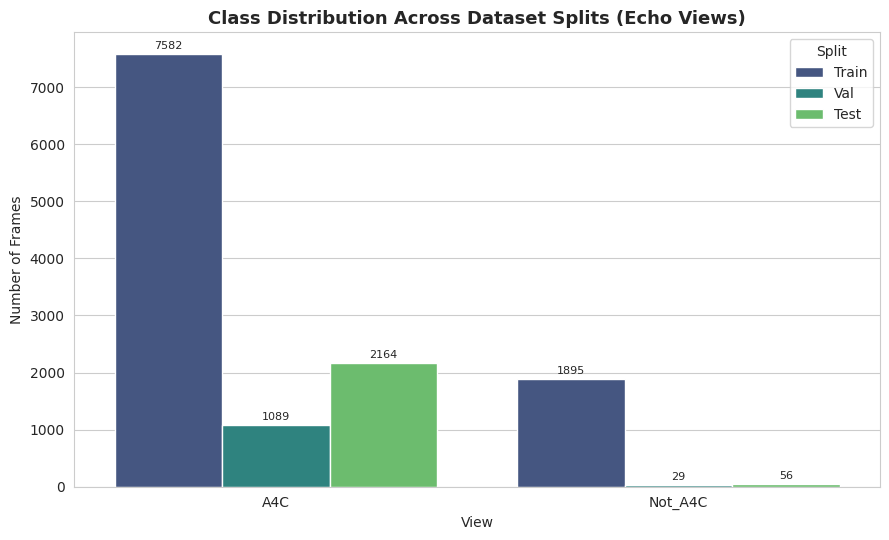

In [ ]:
split_plot_df = counts_df.reset_index().melt(id_vars="index", var_name="Split", value_name="Count")
split_plot_df.rename(columns={"index": "Class"}, inplace=True)

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(data=split_plot_df, x="Class", y="Count", hue="Split", palette="viridis")
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)
plt.title("Class Distribution Across Dataset Splits (Echo Views)", fontsize=13, fontweight="bold")
plt.xlabel("View"); plt.ylabel("Number of Frames")
plt.tight_layout()
plt.show()


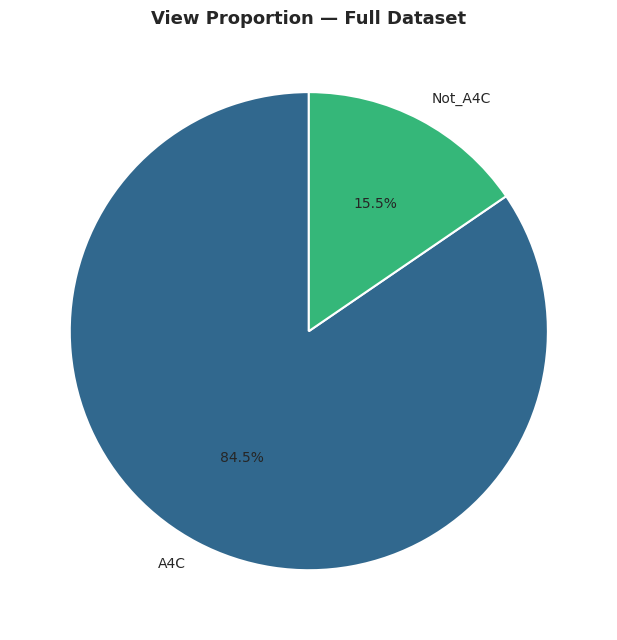

In [ ]:
overall_counts = (counts_df["Train"] + counts_df["Val"] + counts_df["Test"])

plt.figure(figsize=(6.5, 6.5))
colors = sns.color_palette("viridis", num_classes)
plt.pie(
    overall_counts.values, labels=overall_counts.index, autopct="%1.1f%%",
    startangle=90, colors=colors, wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("View Proportion — Full Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


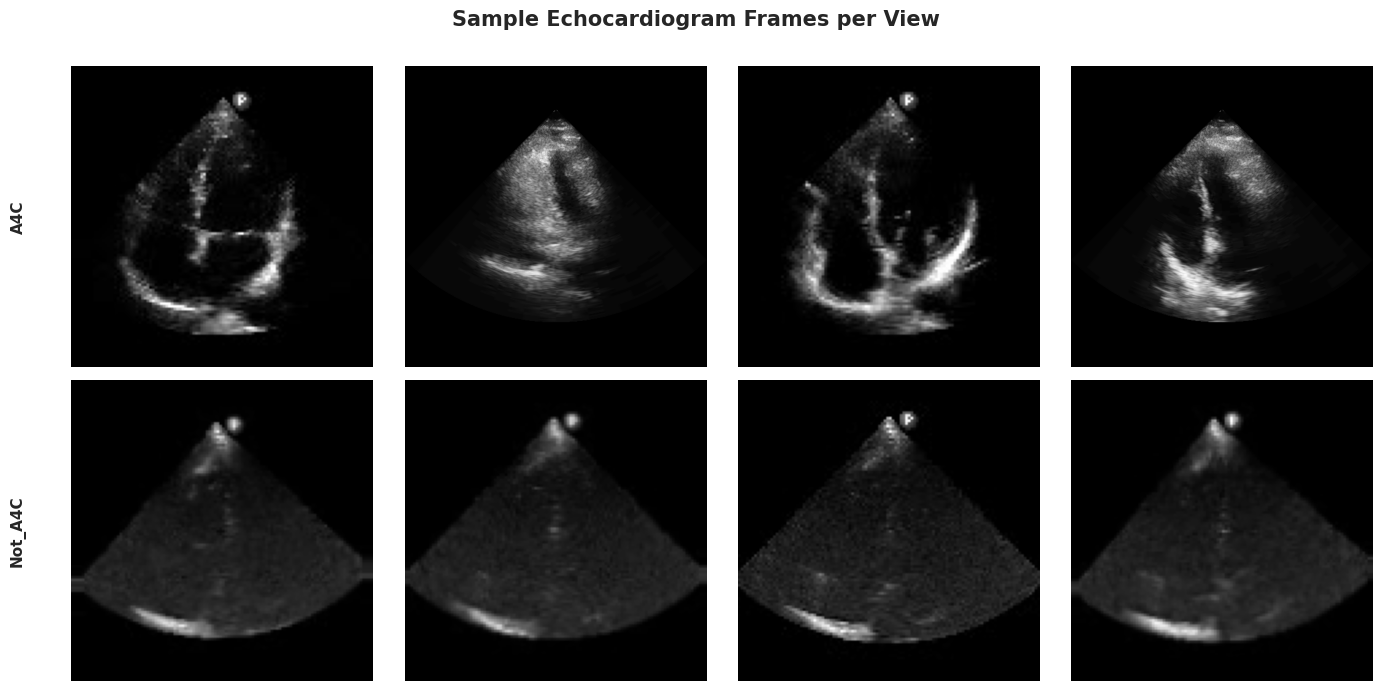

In [ ]:
fig, axes = plt.subplots(num_classes, 4, figsize=(14, 3.4 * num_classes))
fig.suptitle("Sample Echocardiogram Frames per View", fontsize=15, fontweight="bold", y=1.01)

for row, cname in enumerate(class_names):
    class_dir = os.path.join(train_path, cname)
    files_in_class = os.listdir(class_dir)
    sample_files = random.sample(files_in_class, min(4, len(files_in_class)))

    for col in range(4):
        ax = axes[row, col]
        if col < len(sample_files):
            img = cv2.cvtColor(cv2.imread(os.path.join(class_dir, sample_files[col])), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.axis("off")
    axes[row, 0].text(-0.15, 0.5, cname, transform=axes[row, 0].transAxes,
                       fontsize=11, fontweight="bold", va="center", ha="right", rotation=90)

plt.tight_layout()
plt.show()


## **Data Generators, Class Weights, and Config**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score
)

tf.random.set_seed(SEED)

image_size = (224, 224)
batch_size = 32
epochs     = 10   # every model trains for the FULL number of epochs -- no early stopping

WEIGHTS_DIR  = "weights"
RESULTS_DIR  = "results"     # history JSON, metrics JSON, predictions JSON
PLOTS_DIR    = "plots"
for d in (WEIGHTS_DIR, RESULTS_DIR, PLOTS_DIR):
    os.makedirs(d, exist_ok=True)


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.9, 1.1),
    horizontal_flip=False,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=image_size, batch_size=batch_size,
    class_mode="categorical", classes=class_names, shuffle=True, seed=SEED
)
val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=image_size, batch_size=batch_size,
    class_mode="categorical", classes=class_names, shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=image_size, batch_size=batch_size,
    class_mode="categorical", classes=class_names, shuffle=False
)

print("Class indices:", train_generator.class_indices)


Found 9477 images belonging to 2 classes.
Found 1118 images belonging to 2 classes.
Found 2220 images belonging to 2 classes.
Class indices: {'A4C': 0, 'Not_A4C': 1}


In [ ]:
from collections import Counter

counts = Counter(train_generator.classes)
counts_arr = np.array(list(counts.values()))
imbalance_ratio = counts_arr.max() / counts_arr.min()
print(f"Imbalance Ratio after oversampling (max/min class count): {imbalance_ratio:.2f}")

raw_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)


MAX_CLASS_WEIGHT = 5.0
capped_class_weights = np.clip(raw_class_weights, a_min=None, a_max=MAX_CLASS_WEIGHT)
class_weights = dict(enumerate(capped_class_weights))
print("Raw class weights:  ", dict(enumerate(raw_class_weights)))
print("Capped class weights:", class_weights)


Imbalance Ratio after oversampling (max/min class count): 4.00
Raw class weights:   {0: np.float64(0.6249670271696123), 1: np.float64(2.500527704485488)}
Capped class weights: {0: np.float64(0.6249670271696123), 1: np.float64(2.500527704485488)}


## **Reusable Helper Functions**

In [ ]:
import json

def get_checkpoint_path(model_name):
    safe_name = model_name.replace(" ", "_").replace("-", "_")
    return os.path.join(WEIGHTS_DIR, f"{safe_name}_best.keras")

def get_result_paths(model_name):
    safe_name = model_name.replace(" ", "_").replace("-", "_")
    return {
        "history":     os.path.join(RESULTS_DIR, f"{safe_name}_history.json"),
        "metrics":     os.path.join(RESULTS_DIR, f"{safe_name}_metrics.json"),
        "predictions": os.path.join(RESULTS_DIR, f"{safe_name}_predictions.json"),
    }

In [ ]:
def make_callbacks(model_name):

    return [
        ModelCheckpoint(
            filepath=get_checkpoint_path(model_name),
            monitor="val_loss", mode="min",
            save_best_only=True, save_weights_only=False, verbose=1
        ),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_delta=1e-3, min_lr=1e-6, verbose=1),
    ]

In [ ]:
def train_model(model, model_name):
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        class_weight=class_weights,
        callbacks=make_callbacks(model_name),
        verbose=1,
    )
    return history

In [ ]:
def load_best_checkpoint(model_name):
    best_model = tf.keras.models.load_model(get_checkpoint_path(model_name))
    print(f"Loaded best checkpoint for {model_name} from {get_checkpoint_path(model_name)}")
    return best_model

In [ ]:
def save_history_json(history, model_name):
    paths = get_result_paths(model_name)
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(paths["history"], "w") as f:
        json.dump({"model_name": model_name, "history": history_dict}, f, indent=2)
    print("Saved history ->", paths["history"])
    return history_dict

In [ ]:
def plot_training_history(history_dict, model_name, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight="bold")

    axes[0].plot(history_dict["accuracy"], marker="o", label="Train")
    axes[0].plot(history_dict["val_accuracy"], marker="o", label="Validation")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history_dict["loss"], marker="o", label="Train")
    axes[1].plot(history_dict["val_loss"], marker="o", label="Validation")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save:
        safe_name = model_name.replace(" ", "_").replace("-", "_")
        plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_training_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
def evaluate_and_save(model, model_name):
    paths = get_result_paths(model_name)

    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)

    print("=" * 62); print(f"{model_name} — Test Set Performance"); print("=" * 62)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    metrics_payload = {
        "model_name": model_name,
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "classification_report": report,
        "class_names": class_names,
    }
    with open(paths["metrics"], "w") as f:
        json.dump(metrics_payload, f, indent=2)

    predictions_payload = {
        "model_name": model_name,
        "class_names": class_names,
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
        "y_pred_prob": y_pred_prob.tolist(),
    }
    with open(paths["predictions"], "w") as f:
        json.dump(predictions_payload, f)

    print("Saved metrics     ->", paths["metrics"])
    print("Saved predictions ->", paths["predictions"])
    return metrics_payload, predictions_payload

In [ ]:
def plot_single_model_metrics(metrics_payload, save=True):
    model_name = metrics_payload["model_name"]
    scores = {
        "Accuracy": metrics_payload["accuracy"],
        "Precision": metrics_payload["precision"],
        "Recall": metrics_payload["recall"],
        "F1": metrics_payload["f1"],
    }
    plt.figure(figsize=(6, 5))
    ax = sns.barplot(x=list(scores.keys()), y=list(scores.values()), hue=list(scores.keys()),
                      palette="crest", legend=False)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
    plt.title(f"{model_name} — Test Set Metrics", fontsize=13, fontweight="bold")
    plt.ylim(0, 1)
    plt.tight_layout()
    if save:
        safe_name = model_name.replace(" ", "_").replace("-", "_")
        plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_metrics_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
def plot_confusion_matrix_from_arrays(y_true, y_pred, model_name, save=True):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, cbar=True)
    plt.title(f"Confusion Matrix — {model_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    if save:
        safe_name = model_name.replace(" ", "_").replace("-", "_")
        plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_confusion_matrix.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
def binarize_labels(y_true, n_classes):

    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    if n_classes == 2:
        y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])
    return y_true_bin

In [ ]:
def plot_roc_curves_from_arrays(y_true, y_pred_prob, model_name, save=True):
    y_true_bin = binarize_labels(y_true, num_classes)
    y_pred_prob = np.array(y_pred_prob)
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

    plt.figure(figsize=(6.5, 5.5))
    for i, (cname, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, color=color, lw=2, label=f"{cname} (AUC={auc(fpr, tpr):.2f})")

    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
    plt.plot(fpr_micro, tpr_micro, color="black", lw=2, linestyle="--",
              label=f"Micro-avg (AUC={auc(fpr_micro, tpr_micro):.2f})")

    plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}", fontsize=13, fontweight="bold")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    if save:
        safe_name = model_name.replace(" ", "_").replace("-", "_")
        plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_roc_curve.png"), dpi=150, bbox_inches="tight")
    plt.show()


## **Model Architectures**

In [ ]:
def build_transfer_model(base_model_class, num_classes, input_shape=(224, 224, 3),
                          unfreeze_last_n=20):
    """Generic transfer-learning head: partially fine-tuned backbone + GAP + Dense."""
    base = base_model_class(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = True
    for layer in base.layers[:-unfreeze_last_n]:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=outputs)
    return model, base


### **Hybrid CNN–Transformer**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from keras.utils import register_keras_serializable

@register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    """Learnable positional embedding added to a sequence of patch tokens."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_embed = self.add_weight(
            name="pos_embed", shape=(1, num_patches, embed_dim),
            initializer="random_normal", trainable=True
        )

    def call(self, x):
        return x + self.pos_embed

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.pos_embed.shape[1], "embed_dim": self.pos_embed.shape[2]})
        return config

In [ ]:
def transformer_encoder_block(x, num_heads, key_dim, ff_dim, dropout=0.1):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn_output = layers.Dense(ff_dim, activation="gelu")(x)
    ffn_output = layers.Dense(x.shape[-1])(ffn_output)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)
    return x

In [ ]:
def build_hybrid_cnn_transformer(input_shape=(224, 224, 3), num_classes=num_classes,
                                  embed_dim=128, num_transformer_blocks=4,
                                  num_heads=4, ff_dim=256, dropout=0.1, unfreeze_last_n=20):
    inputs = layers.Input(shape=input_shape)

    # --- CNN branch: local feature extraction ---
    cnn_backbone = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    cnn_backbone.trainable = True
    for layer in cnn_backbone.layers[:-unfreeze_last_n]:
        layer.trainable = False

    feature_map = cnn_backbone(inputs)                       # (7, 7, 1280)
    x = layers.Conv2D(embed_dim, kernel_size=1, padding="same")(feature_map)

    h, w = x.shape[1], x.shape[2]
    num_patches = h * w
    x = layers.Reshape((num_patches, embed_dim))(x)           # sequence of visual tokens
    x = PositionalEmbedding(num_patches, embed_dim)(x)

    # --- Transformer branch: global context modelling ---
    for _ in range(num_transformer_blocks):
        x = transformer_encoder_block(x, num_heads=num_heads, key_dim=embed_dim // num_heads, ff_dim=ff_dim, dropout=dropout)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, cnn_backbone

## **ResNet50**

In [ ]:
resnet_model, resnet_base = build_transfer_model(ResNet50, num_classes, input_shape=(*image_size, 3), unfreeze_last_n=20)
resnet_model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)
resnet_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,771,714 (94.50 MB)

 Trainable params: 10,113,794 (38.58 MB)

 Non-trainable params: 14,657,920 (55.92 MB)

In [ ]:
resnet_history_obj = train_model(resnet_model, "ResNet50")


Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8386 - loss: 0.4006
Epoch 1: val_loss improved from None to 0.88078, saving model to weights/ResNet50_best.keras

Epoch 1: finished saving model to weights/ResNet50_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 185s 553ms/step - accuracy: 0.8936 - loss: 0.3319 - val_accuracy: 0.7299 - val_loss: 0.8808 - learning_rate: 5.0000e-05
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9513 - loss: 0.2665
Epoch 2: val_loss improved from 0.88078 to 0.15017, saving model to weights/ResNet50_best.keras

Epoch 2: finished saving model to weights/ResNet50_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 146s 491ms/step - accuracy: 0.9593 - loss: 0.2532 - val_accuracy: 0.9991 - val_loss: 0.1502 - learning_rate: 5.0000e-05
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9777 - loss: 0.2252
Epoch 3: val_loss improved from 0.15017 to 0.14621, saving model to weights/ResNet50_best.keras

Epoch 3: finished saving m

In [ ]:
resnet_model = load_best_checkpoint("ResNet50")


Loaded best checkpoint for ResNet50 from weights/ResNet50_best.keras


In [ ]:
resnet_history = save_history_json(resnet_history_obj, "ResNet50")


Saved history -> results/ResNet50_history.json


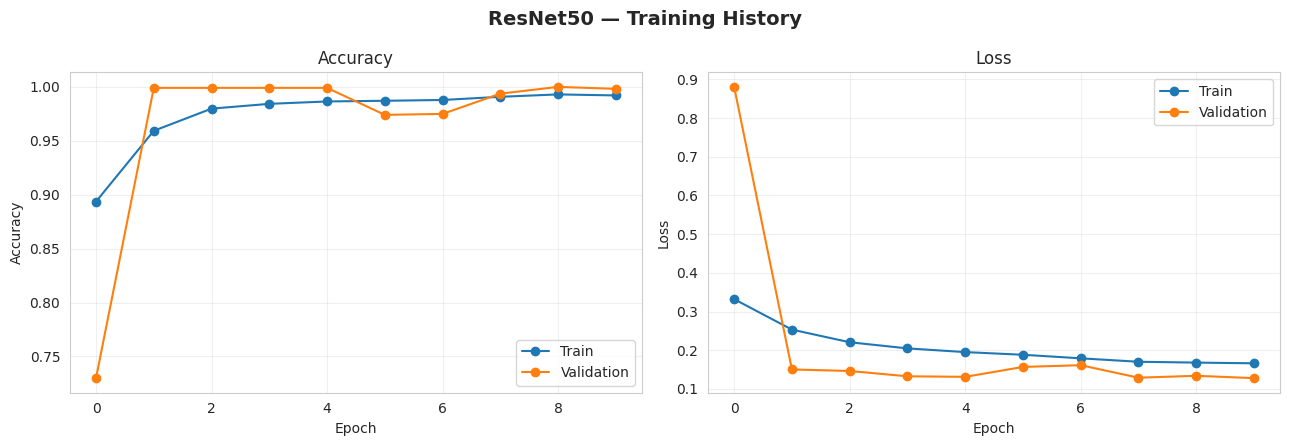

In [ ]:
plot_training_history(resnet_history, "ResNet50")


In [ ]:
resnet_metrics, resnet_predictions = evaluate_and_save(resnet_model, "ResNet50")


ResNet50 — Test Set Performance
Accuracy : 0.9977
Precision: 0.9979
Recall   : 0.9977
F1-score : 0.9978

              precision    recall  f1-score   support

         A4C       1.00      1.00      1.00      2164
     Not_A4C       0.92      1.00      0.96        56

    accuracy                           1.00      2220
   macro avg       0.96      1.00      0.98      2220
weighted avg       1.00      1.00      1.00      2220

Saved metrics     -> results/ResNet50_metrics.json
Saved predictions -> results/ResNet50_predictions.json


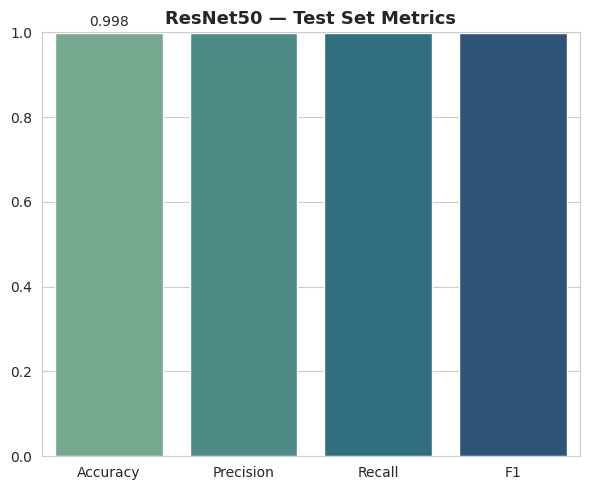

In [ ]:
plot_single_model_metrics(resnet_metrics)


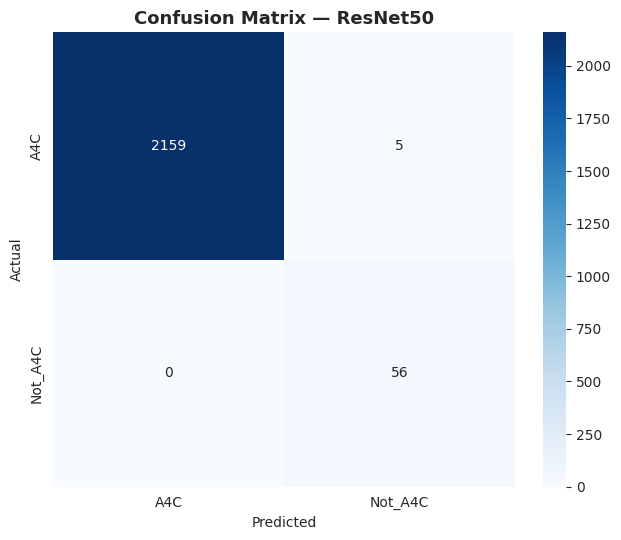

In [ ]:
plot_confusion_matrix_from_arrays(resnet_predictions["y_true"], resnet_predictions["y_pred"], "ResNet50")


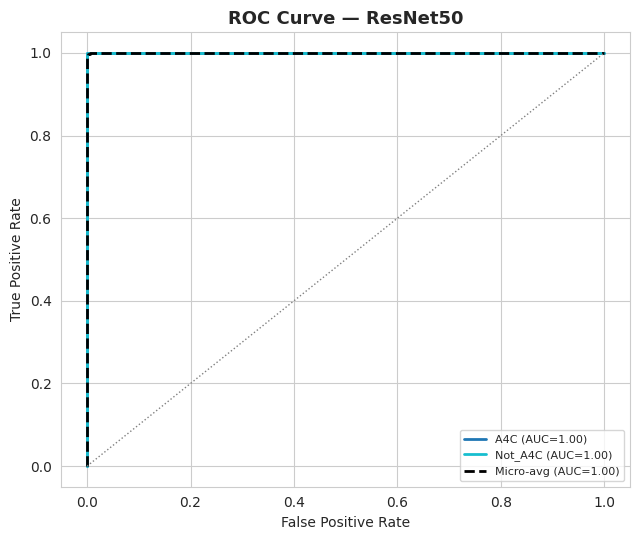

In [ ]:
plot_roc_curves_from_arrays(resnet_predictions["y_true"], resnet_predictions["y_pred_prob"], "ResNet50")


## **DenseNet121**

In [ ]:
densenet_model, densenet_base = build_transfer_model(DenseNet121, num_classes, input_shape=(*image_size, 3), unfreeze_last_n=20)
densenet_model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)
densenet_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,697,218 (29.36 MB)

 Trainable params: 1,025,346 (3.91 MB)

 Non-trainable params: 6,671,872 (25.45 MB)

In [ ]:
densenet_history_obj = train_model(densenet_model, "DenseNet121")


Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.8092 - loss: 0.4437
Epoch 1: val_loss improved from None to 0.14960, saving model to weights/DenseNet121_best.keras

Epoch 1: finished saving model to weights/DenseNet121_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 237s 663ms/step - accuracy: 0.8811 - loss: 0.3445 - val_accuracy: 0.9946 - val_loss: 0.1496 - learning_rate: 5.0000e-05
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9448 - loss: 0.2584
Epoch 2: val_loss improved from 0.14960 to 0.14141, saving model to weights/DenseNet121_best.keras

Epoch 2: finished saving model to weights/DenseNet121_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 147s 495ms/step - accuracy: 0.9556 - loss: 0.2471 - val_accuracy: 0.9955 - val_loss: 0.1414 - learning_rate: 5.0000e-05
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.9699 - loss: 0.2276
Epoch 3: val_loss improved from 0.14141 to 0.13737, saving model to weights/DenseNet121_best.keras

Epoch 3: fi

In [ ]:
densenet_model = load_best_checkpoint("DenseNet121")


Loaded best checkpoint for DenseNet121 from weights/DenseNet121_best.keras


In [ ]:
densenet_history = save_history_json(densenet_history_obj, "DenseNet121")


Saved history -> results/DenseNet121_history.json


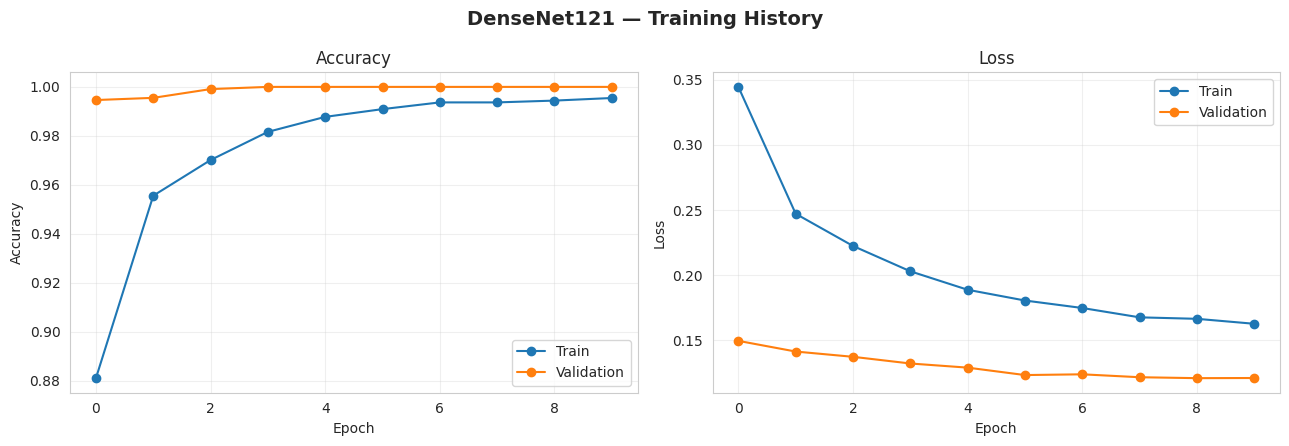

In [ ]:
plot_training_history(densenet_history, "DenseNet121")


In [ ]:
densenet_metrics, densenet_predictions = evaluate_and_save(densenet_model, "DenseNet121")


DenseNet121 — Test Set Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

              precision    recall  f1-score   support

         A4C       1.00      1.00      1.00      2164
     Not_A4C       1.00      1.00      1.00        56

    accuracy                           1.00      2220
   macro avg       1.00      1.00      1.00      2220
weighted avg       1.00      1.00      1.00      2220

Saved metrics     -> results/DenseNet121_metrics.json
Saved predictions -> results/DenseNet121_predictions.json


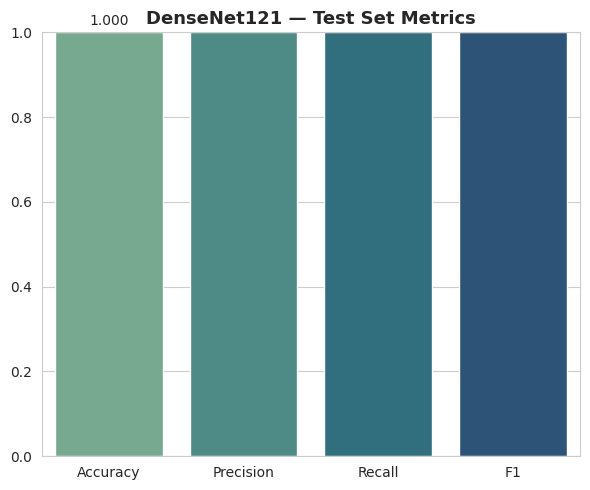

In [ ]:
plot_single_model_metrics(densenet_metrics)


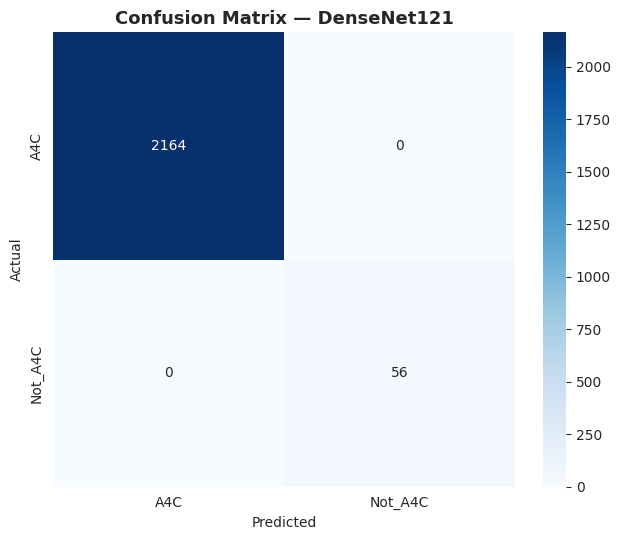

In [ ]:
plot_confusion_matrix_from_arrays(densenet_predictions["y_true"], densenet_predictions["y_pred"], "DenseNet121")


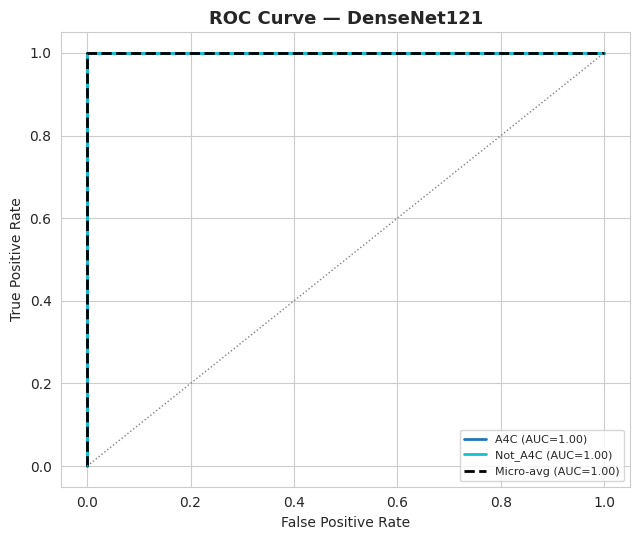

In [ ]:
plot_roc_curves_from_arrays(densenet_predictions["y_true"], densenet_predictions["y_pred_prob"], "DenseNet121")


## **Hybrid CNN–Transformer**

In [ ]:
hybrid_model, hybrid_backbone = build_hybrid_cnn_transformer(input_shape=(*image_size, 3), num_classes=num_classes, unfreeze_last_n=20)
hybrid_model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)
hybrid_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_3[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 128) │    163,968 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 128)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 49, 128)   │      6,272 │ reshape[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 128)   │     66,048 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 49, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 128)   │          0 │ positional_embed… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 49, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 49, 128)   │     32,896 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 49, 128)   │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 49, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 49, 256)   │     33,024 │ layer_normalizat

 Total params: 2,992,962 (11.42 MB)

 Trainable params: 1,940,546 (7.40 MB)

 Non-trainable params: 1,052,416 (4.01 MB)

In [ ]:
hybrid_history_obj = train_model(hybrid_model, "Hybrid CNN-Transformer")


Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9240 - loss: 0.2849
Epoch 1: val_loss improved from None to 0.14055, saving model to weights/Hybrid_CNN_Transformer_best.keras

Epoch 1: finished saving model to weights/Hybrid_CNN_Transformer_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 250s 663ms/step - accuracy: 0.9638 - loss: 0.2400 - val_accuracy: 0.9982 - val_loss: 0.1406 - learning_rate: 5.0000e-05
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9915 - loss: 0.2020
Epoch 2: val_loss improved from 0.14055 to 0.12530, saving model to weights/Hybrid_CNN_Transformer_best.keras

Epoch 2: finished saving model to weights/Hybrid_CNN_Transformer_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 145s 486ms/step - accuracy: 0.9932 - loss: 0.1956 - val_accuracy: 1.0000 - val_loss: 0.1253 - learning_rate: 5.0000e-05
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9964 - loss: 0.1805
Epoch 3: val_loss improved from 0.12530 to 0.11962, saving model to

In [ ]:
hybrid_history = save_history_json(hybrid_history_obj, "Hybrid CNN-Transformer")

Saved history -> results/Hybrid_CNN_Transformer_history.json


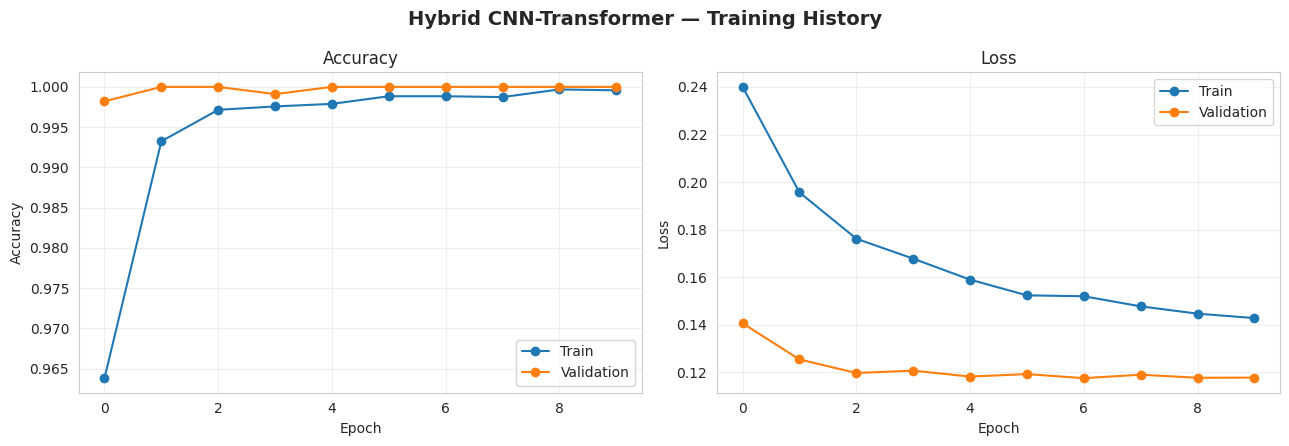

In [ ]:
plot_training_history(hybrid_history, "Hybrid CNN-Transformer")

In [ ]:
hybrid_metrics, hybrid_predictions = evaluate_and_save(hybrid_model, "Hybrid CNN-Transformer")

Hybrid CNN-Transformer — Test Set Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

              precision    recall  f1-score   support

         A4C       1.00      1.00      1.00      2164
     Not_A4C       1.00      1.00      1.00        56

    accuracy                           1.00      2220
   macro avg       1.00      1.00      1.00      2220
weighted avg       1.00      1.00      1.00      2220

Saved metrics     -> results/Hybrid_CNN_Transformer_metrics.json
Saved predictions -> results/Hybrid_CNN_Transformer_predictions.json


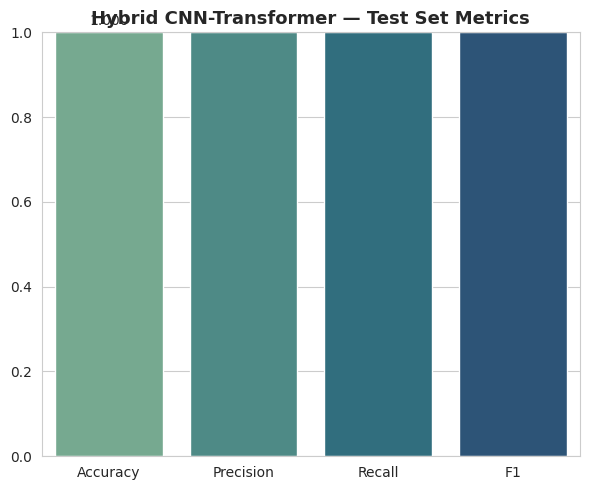

In [ ]:
plot_single_model_metrics(hybrid_metrics)

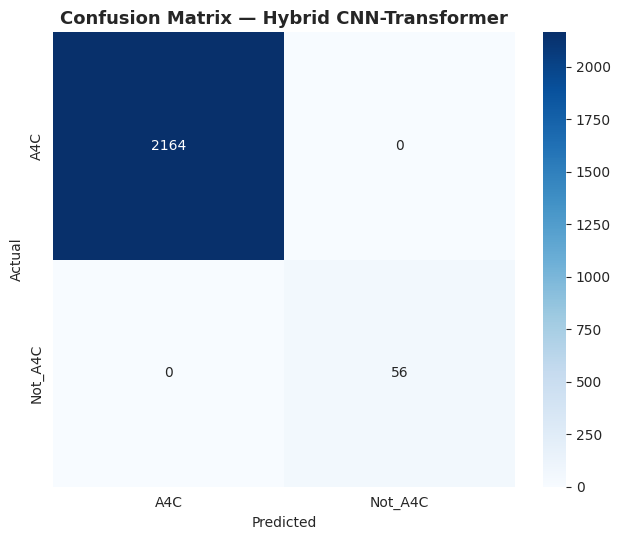

In [ ]:
plot_confusion_matrix_from_arrays(hybrid_predictions["y_true"], hybrid_predictions["y_pred"], "Hybrid CNN-Transformer")

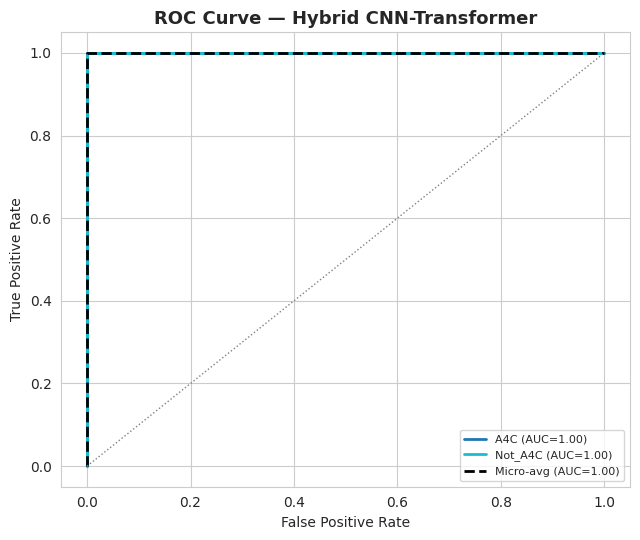

In [ ]:
plot_roc_curves_from_arrays(hybrid_predictions["y_true"], hybrid_predictions["y_pred_prob"], "Hybrid CNN-Transformer")

## **Final Model Comparison**

In [ ]:
import glob

metrics_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_metrics.json")))
predictions_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_predictions.json")))
history_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_history.json")))

print("Metrics files found:", metrics_files)
print("Predictions files found:", predictions_files)
print("History files found:", history_files)

loaded_metrics = []
for fp in metrics_files:
    with open(fp) as f:
        loaded_metrics.append(json.load(f))

loaded_predictions = {}
for fp in predictions_files:
    with open(fp) as f:
        payload = json.load(f)
        loaded_predictions[payload["model_name"]] = payload

df_results = pd.DataFrame([
    {"Model": m["model_name"], "Accuracy": m["accuracy"], "Precision": m["precision"],
     "Recall": m["recall"], "F1": m["f1"]}
    for m in loaded_metrics
]).sort_values(by="F1", ascending=False).reset_index(drop=True)

df_results


Metrics files found: ['results/DenseNet121_metrics.json', 'results/Hybrid_CNN_Transformer_metrics.json', 'results/ResNet50_metrics.json']
Predictions files found: ['results/DenseNet121_predictions.json', 'results/Hybrid_CNN_Transformer_predictions.json', 'results/ResNet50_predictions.json']
History files found: ['results/DenseNet121_history.json', 'results/Hybrid_CNN_Transformer_history.json', 'results/ResNet50_history.json']


,Model,Accuracy,Precision,Recall,F1
0,DenseNet121,1.000000,1.000000,1.000000,1.000000
1,Hybrid CNN-Transformer,1.000000,1.000000,1.000000,1.000000
2,ResNet50,0.997748,0.997932,0.997748,0.997795


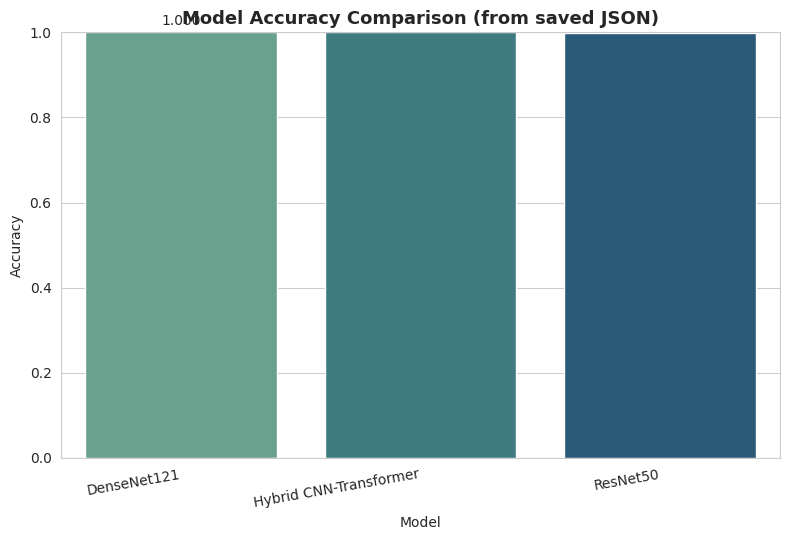

In [ ]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x="Model", y="Accuracy", hue="Model", palette="crest", legend=False)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
plt.title("Model Accuracy Comparison (from saved JSON)", fontsize=13, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()


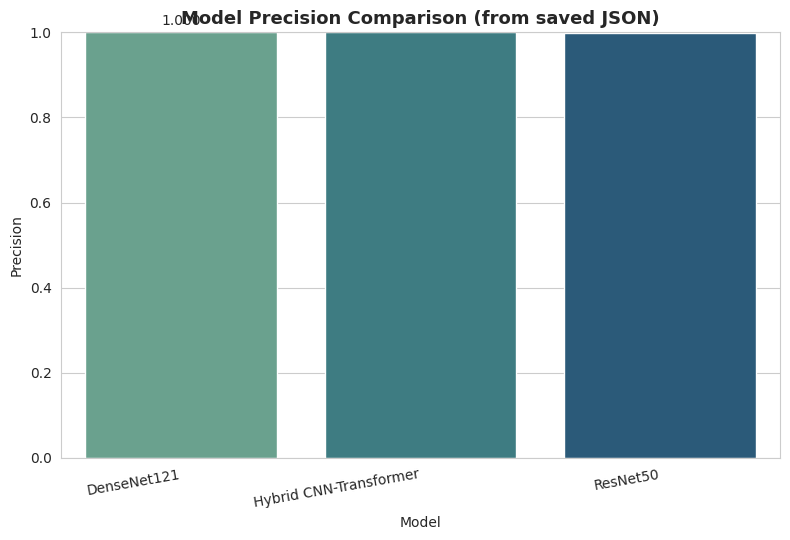

In [ ]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x="Model", y="Precision", hue="Model", palette="crest", legend=False)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
plt.title("Model Precision Comparison (from saved JSON)", fontsize=13, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_precision.png"), dpi=150, bbox_inches="tight")
plt.show()


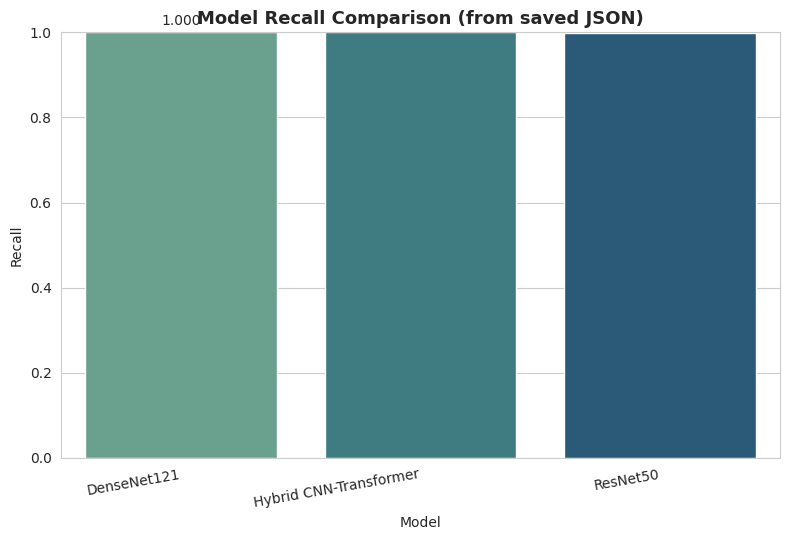

In [ ]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x="Model", y="Recall", hue="Model", palette="crest", legend=False)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
plt.title("Model Recall Comparison (from saved JSON)", fontsize=13, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_recall.png"), dpi=150, bbox_inches="tight")
plt.show()


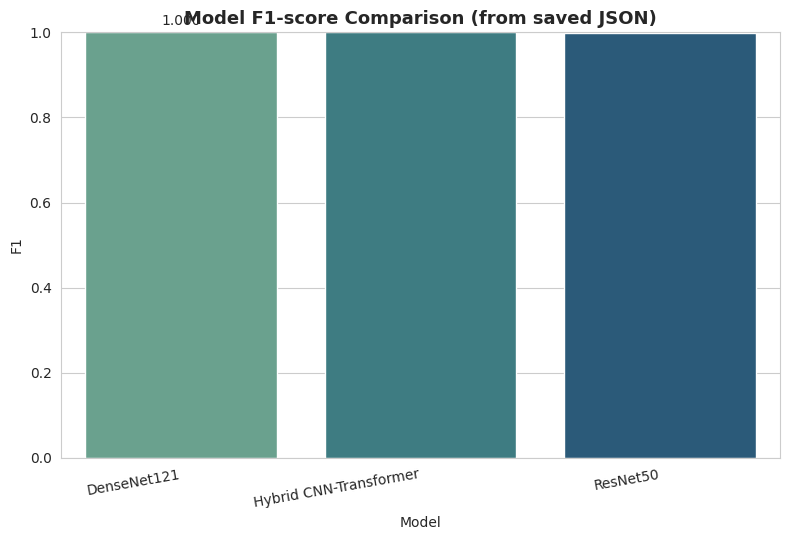

In [ ]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x="Model", y="F1", hue="Model", palette="crest", legend=False)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
plt.title("Model F1-score Comparison (from saved JSON)", fontsize=13, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_f1.png"), dpi=150, bbox_inches="tight")
plt.show()


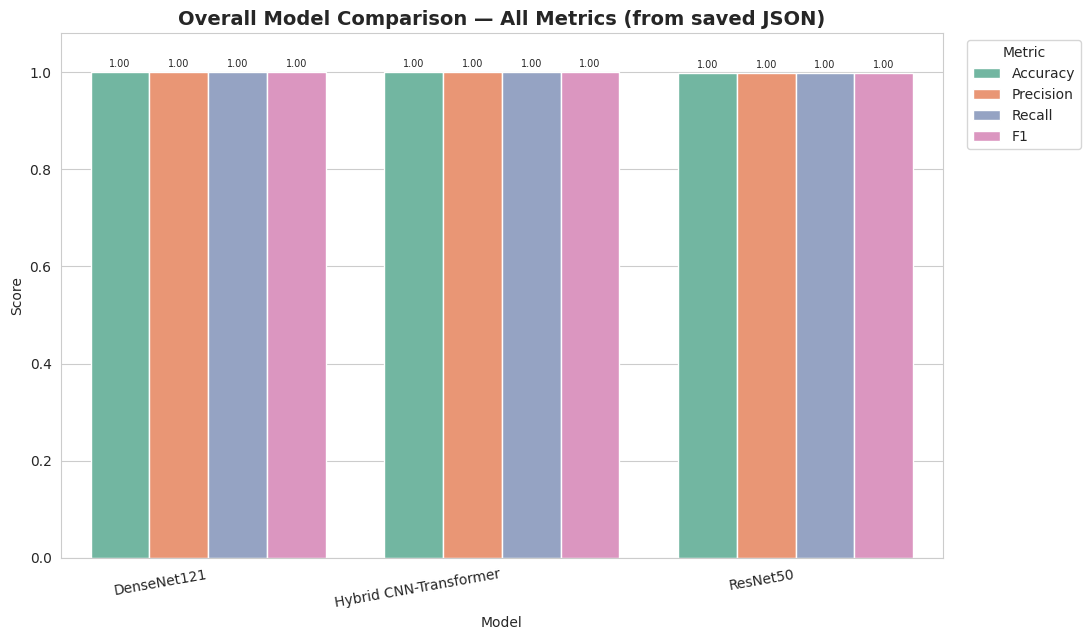

In [ ]:
metrics_melt = df_results.melt(
    id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Metric", value_name="Score"
)

plt.figure(figsize=(11, 6.5))
ax = sns.barplot(data=metrics_melt, x="Model", y="Score", hue="Metric", palette="Set2")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
plt.title("Overall Model Comparison — All Metrics (from saved JSON)", fontsize=14, fontweight="bold")
plt.ylim(0, 1.08)
plt.xlabel("Model"); plt.ylabel("Score")
plt.xticks(rotation=10, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_all_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()


### **Confusion Matrices — All Models (from saved predictions JSON)**

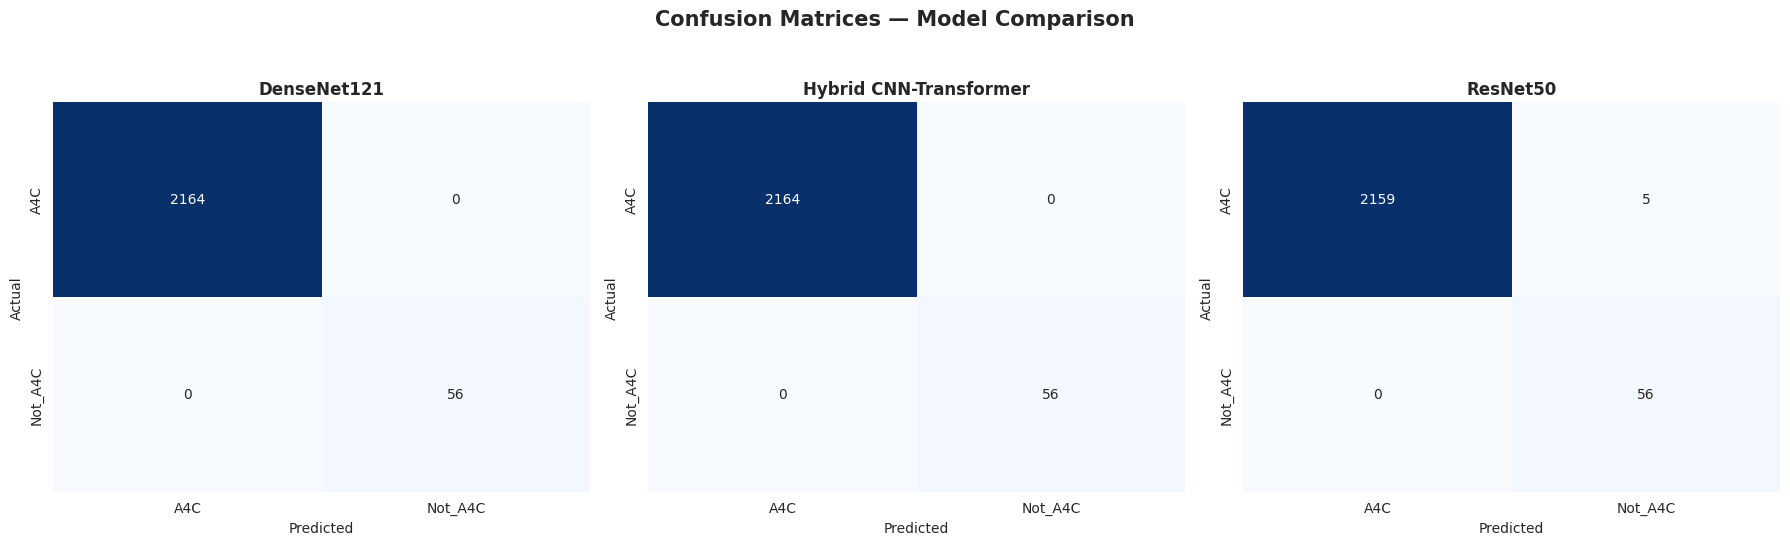

In [ ]:
model_order = df_results["Model"].tolist()
n_models = len(model_order)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5.2))
if n_models == 1:
    axes = [axes]

for ax, model_name in zip(axes, model_order):
    payload = loaded_predictions[model_name]
    cm = confusion_matrix(payload["y_true"], payload["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=payload["class_names"], yticklabels=payload["class_names"],
                cbar=False, ax=ax)
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Model Comparison", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()


### **ROC Curves — All Models (from saved predictions JSON)**

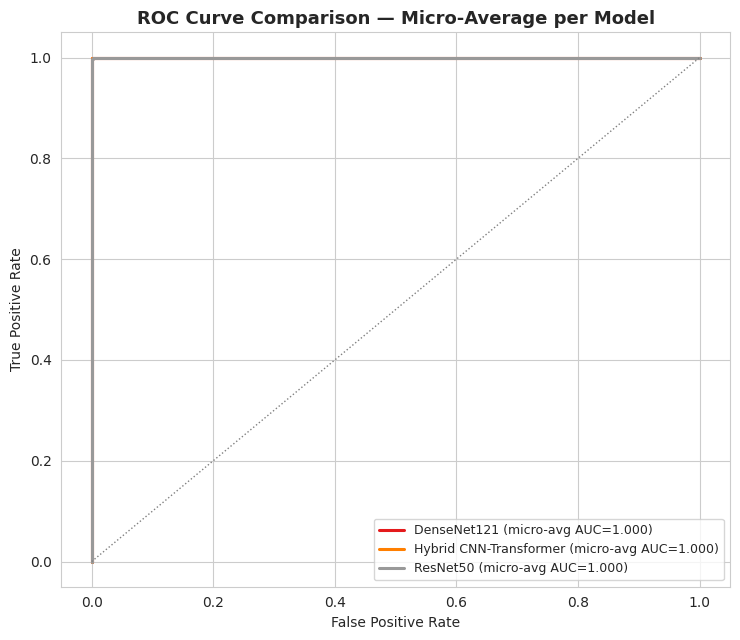

In [ ]:
plt.figure(figsize=(7.5, 6.5))
colors = plt.cm.Set1(np.linspace(0, 1, n_models))

for model_name, color in zip(model_order, colors):
    payload = loaded_predictions[model_name]
    y_true = np.array(payload["y_true"])
    y_pred_prob = np.array(payload["y_pred_prob"])
    cnames = payload["class_names"]
    n_cls = len(cnames)

    y_true_bin = label_binarize(y_true, classes=range(n_cls))
    if n_cls == 2:
        y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color=color, lw=2.2, label=f"{model_name} (micro-avg AUC={auc_micro:.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Micro-Average per Model", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


### **Best Model**

In [ ]:
best_model_name = df_results.iloc[0]["Model"]
print(f"Best model (by F1-score, from saved JSON): {best_model_name}")
df_results

Best model (by F1-score, from saved JSON): DenseNet121


,Model,Accuracy,Precision,Recall,F1
0,DenseNet121,1.000000,1.000000,1.000000,1.000000
1,Hybrid CNN-Transformer,1.000000,1.000000,1.000000,1.000000
2,ResNet50,0.997748,0.997932,0.997748,0.997795


#### **Test Predictions**

In [ ]:
weights_dir = "weights"

resnet_model = tf.keras.models.load_model(
    os.path.join(weights_dir, "ResNet50_best.keras")
)

densenet_model = tf.keras.models.load_model(
    os.path.join(weights_dir, "DenseNet121_best.keras")
)

hybrid_model = tf.keras.models.load_model(
    os.path.join(weights_dir, "Hybrid_CNN_Transformer_best.keras"),
    custom_objects={
        "PositionalEmbedding": PositionalEmbedding
    }
)

print("All models loaded successfully.")

All models loaded successfully.


In [ ]:
test_image_paths = []

for class_name in class_names:
    class_path = os.path.join(test_path, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if img_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
            test_image_paths.append(img_path)

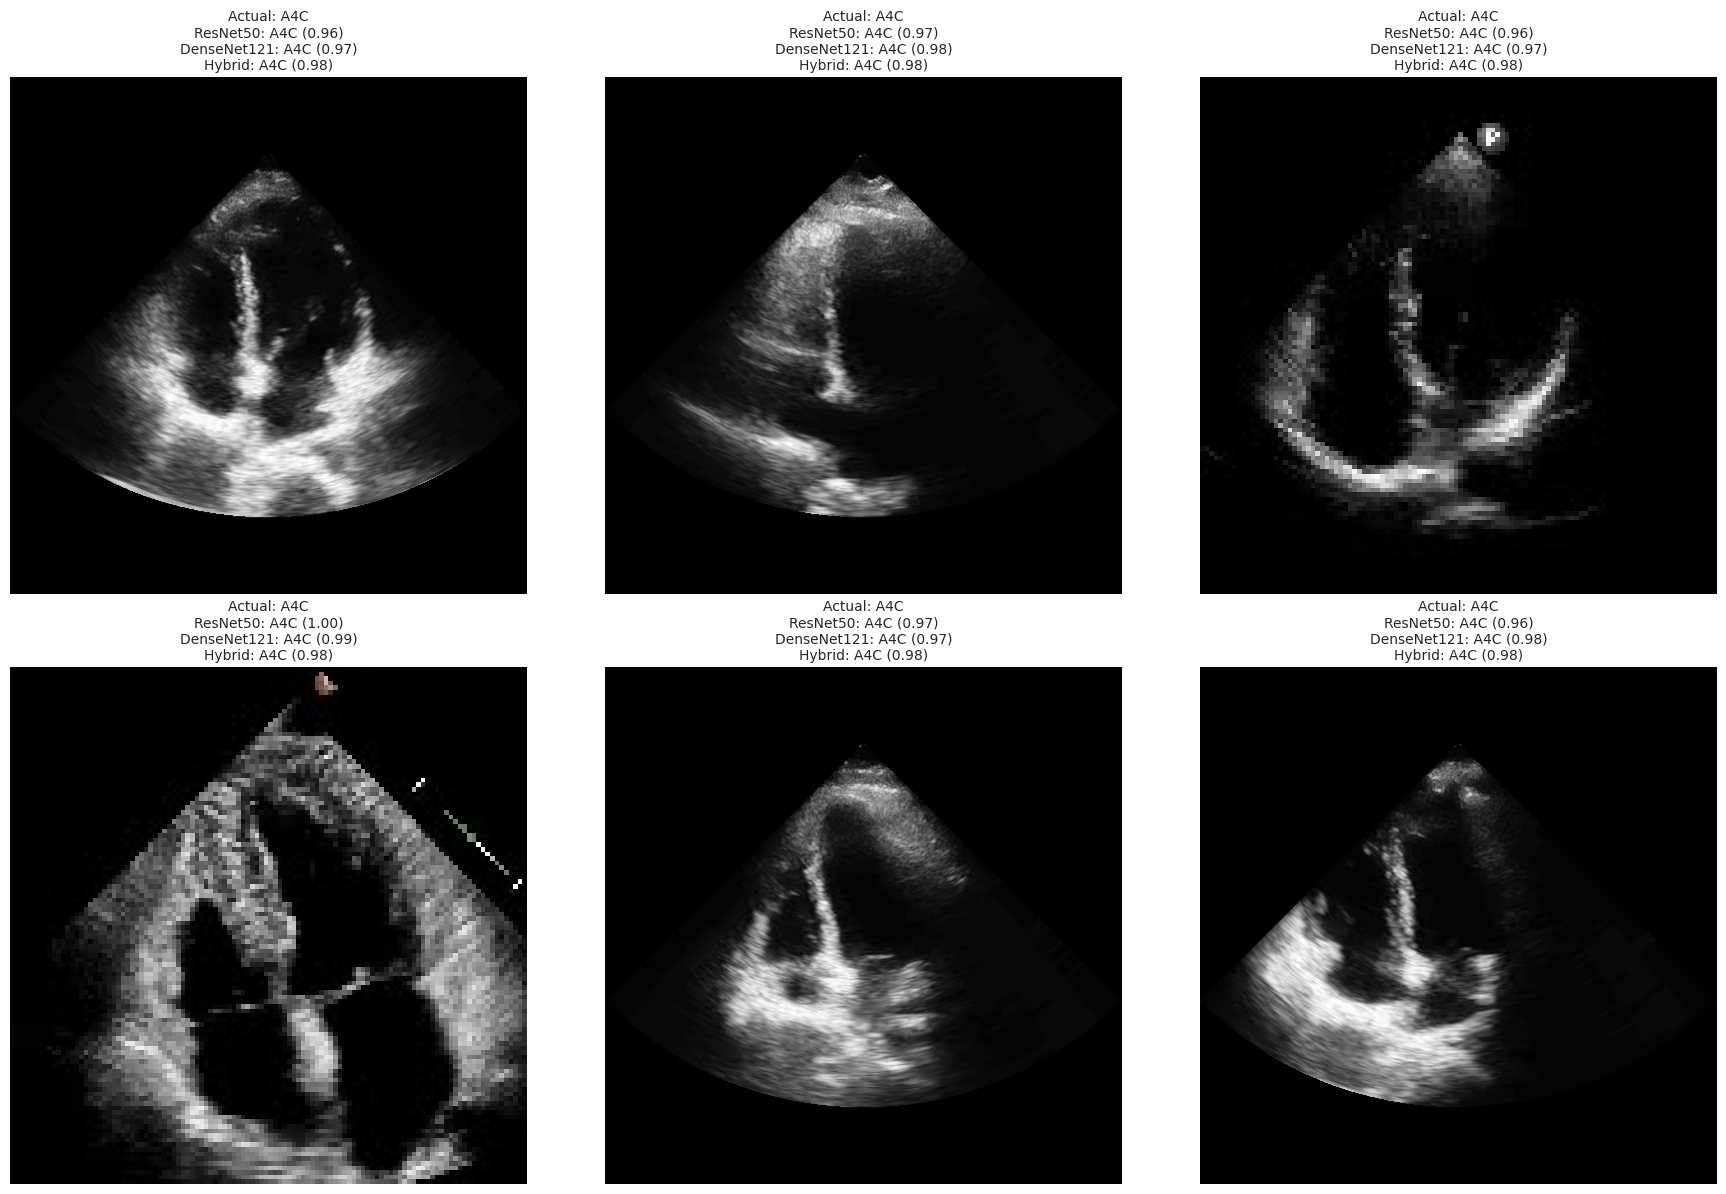

In [ ]:
selected_images = random.sample(test_image_paths, 6)

plt.figure(figsize=(18, 12))
for i, img_path in enumerate(selected_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, image_size)
    img_preprocessed = img_resized.astype(np.float32) / 255.0
    img_batch = np.expand_dims(img_preprocessed, axis=0)
    actual_label = os.path.basename(
        os.path.dirname(img_path)
    )
    pred_resnet_prob = resnet_model.predict(
        img_batch, verbose=0
    )[0]

    pred_densenet_prob = densenet_model.predict(
        img_batch, verbose=0
    )[0]

    pred_hybrid_prob = hybrid_model.predict(
        img_batch, verbose=0
    )[0]

    pred_resnet_idx = np.argmax(pred_resnet_prob)
    pred_densenet_idx = np.argmax(pred_densenet_prob)
    pred_hybrid_idx = np.argmax(pred_hybrid_prob)
    pred_resnet_label = class_names[pred_resnet_idx]
    pred_densenet_label = class_names[pred_densenet_idx]
    pred_hybrid_label = class_names[pred_hybrid_idx]
    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(img)
    ax.set_title(
        f"Actual: {actual_label}\n"
        f"ResNet50: {pred_resnet_label} "
        f"({pred_resnet_prob[pred_resnet_idx]:.2f})\n"
        f"DenseNet121: {pred_densenet_label} "
        f"({pred_densenet_prob[pred_densenet_idx]:.2f})\n"
        f"Hybrid: {pred_hybrid_label} "
        f"({pred_hybrid_prob[pred_hybrid_idx]:.2f})",
        fontsize=10
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

#### **Download Files**

In [ ]:
# Create a zip archive of the weights folder
shutil.make_archive('weights', 'zip', WEIGHTS_DIR)
print(f"Created weights.zip containing {WEIGHTS_DIR}/")

# Create a zip archive of the results folder
shutil.make_archive('results', 'zip', RESULTS_DIR)
print(f"Created results.zip containing {RESULTS_DIR}/")

Created weights.zip containing weights/
Created results.zip containing results/


In [ ]:
from google.colab import files

# Download weights.zip
files.download('weights.zip')

# Download results.zip
files.download('results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>